In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.DataFrame()
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

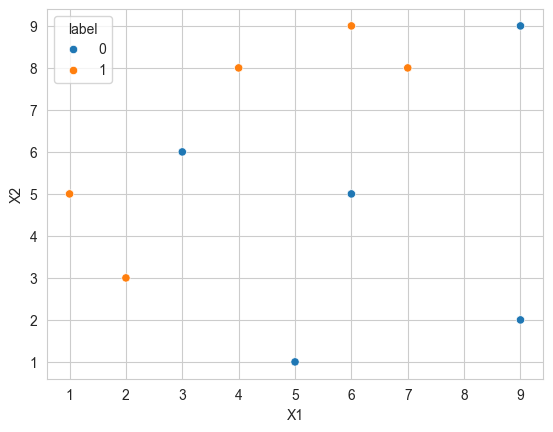

In [3]:
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

def plot_tree_and_decision_region(X,y):
    dt = DecisionTreeClassifier(max_depth=1)
    dt.fit(X,y)
    plt.figure(figsize=(8,6))
    plot_tree(
        dt,
        feature_names=X.columns,
        class_names=[str(int(cls)) for cls in np.unique(y)],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.show()
    plt.figure(figsize=(8,6))
    plot_decision_regions(X.values,y.values,clf=dt, legend=2)
    plt.show()
    return dt

### 1. Calculate Model Weight

In [5]:
df['weight'] = 1 / df.shape[0]
df

,X1,X2,label,weight
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


### 2. Train DT

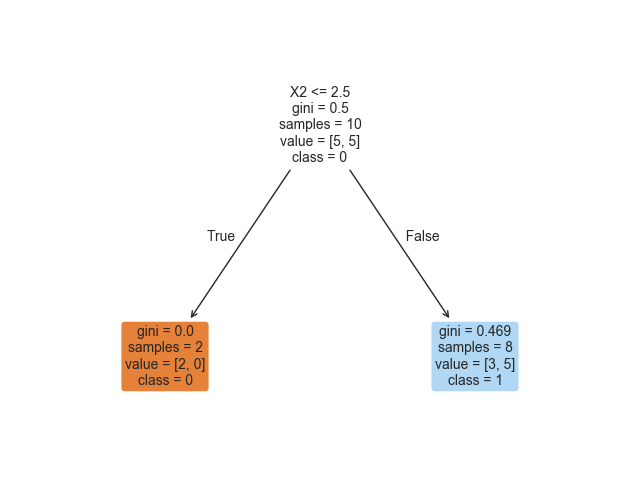

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


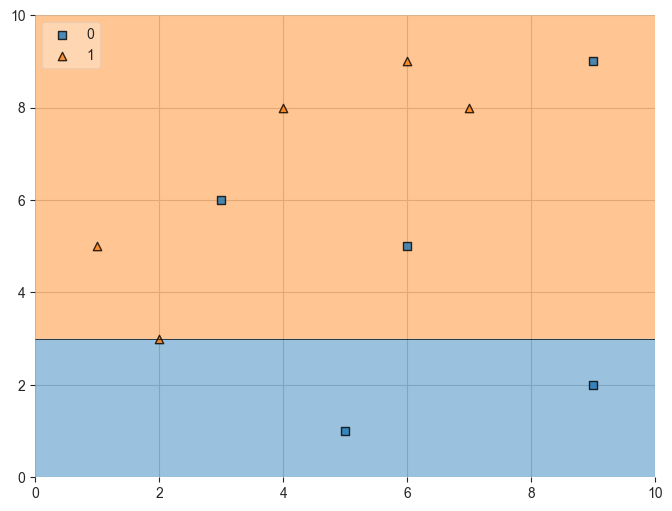

In [6]:
X = df.iloc[:,:2]
y = df.iloc[:,2]
dt1 = plot_tree_and_decision_region(X,y)

### 3. Calculate y_pred

In [7]:
df['y_pred'] = dt1.predict(X)
df

,X1,X2,label,weight,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


# 4. Alpha

In [8]:
def calculate_error(df):
    return sum(abs(df['label'] - df['y_pred']))/10

In [9]:
def calculate_alpha(error):
    return 0.5 * np.log((1-error)/(error + 0.0000001))

In [10]:
error = calculate_error(df)
error

0.3

In [11]:
alpha1 = calculate_alpha(error)
alpha1

np.float64(0.4236487635269629)

### 5. Update Weight

In [12]:
def update_weight(row, alpha):
    if row['label'] == row['y_pred']:
        return row['weight'] * np.exp(-alpha)
    else:
        return row['weight'] * np.exp(alpha)

In [13]:
df['updated_weight'] = df.apply(lambda row: update_weight(row=row,alpha=alpha1),axis=1)
df

,X1,X2,label,weight,y_pred,updated_weight
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,1,0.152752
3,4,8,1,0.1,1,0.065465
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,1,0.065465
6,6,5,0,0.1,1,0.152752
7,7,8,1,0.1,1,0.065465
8,9,9,0,0.1,1,0.152752
9,9,2,0,0.1,0,0.065465


### 6. Normalized Weight

In [14]:
df['normalized_weight'] = df['updated_weight'] / df['updated_weight'].sum()
df

,X1,X2,label,weight,y_pred,updated_weight,normalized_weight
0,1,5,1,0.1,1,0.065465,0.071429
1,2,3,1,0.1,1,0.065465,0.071429
2,3,6,0,0.1,1,0.152752,0.166667
3,4,8,1,0.1,1,0.065465,0.071429
4,5,1,0,0.1,0,0.065465,0.071429
5,6,9,1,0.1,1,0.065465,0.071429
6,6,5,0,0.1,1,0.152752,0.166667
7,7,8,1,0.1,1,0.065465,0.071429
8,9,9,0,0.1,1,0.152752,0.166667
9,9,2,0,0.1,0,0.065465,0.071429


### 7. Range

In [15]:
temp = np.cumsum(df['normalized_weight'])

df['cumsum_lower'] = temp - df['normalized_weight']
df['cumsum_upper'] = temp 
df

,X1,X2,label,weight,y_pred,updated_weight,normalized_weight,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065465,0.071429,0.000000,0.071429
1,2,3,1,0.1,1,0.065465,0.071429,0.071429,0.142857
2,3,6,0,0.1,1,0.152752,0.166667,0.142857,0.309524
3,4,8,1,0.1,1,0.065465,0.071429,0.309524,0.380952
4,5,1,0,0.1,0,0.065465,0.071429,0.380952,0.452381
5,6,9,1,0.1,1,0.065465,0.071429,0.452381,0.523810
6,6,5,0,0.1,1,0.152752,0.166667,0.523810,0.690476
7,7,8,1,0.1,1,0.065465,0.071429,0.690476,0.761905
8,9,9,0,0.1,1,0.152752,0.166667,0.761905,0.928571
9,9,2,0,0.1,0,0.065465,0.071429,0.928571,1.000000


# Iter - 2

In [16]:
def create_new_sample(df):
    indices = []
    
    for _ in range(df.shape[0]):
        num = np.random.random()
        for index, row in df.iterrows():
            if (row['cumsum_lower'] < num) and (row['cumsum_upper'] >= num):
                indices.append(index)
    return indices

In [17]:
index_values = create_new_sample(df)
index_values

[3, 1, 5, 8, 0, 6, 0, 5, 4, 6]

In [18]:
df2 = df.iloc[index_values,:4]
df2

,X1,X2,label,weight
3,4,8,1,0.1
1,2,3,1,0.1
5,6,9,1,0.1
8,9,9,0,0.1
0,1,5,1,0.1
6,6,5,0,0.1
0,1,5,1,0.1
5,6,9,1,0.1
4,5,1,0,0.1
6,6,5,0,0.1


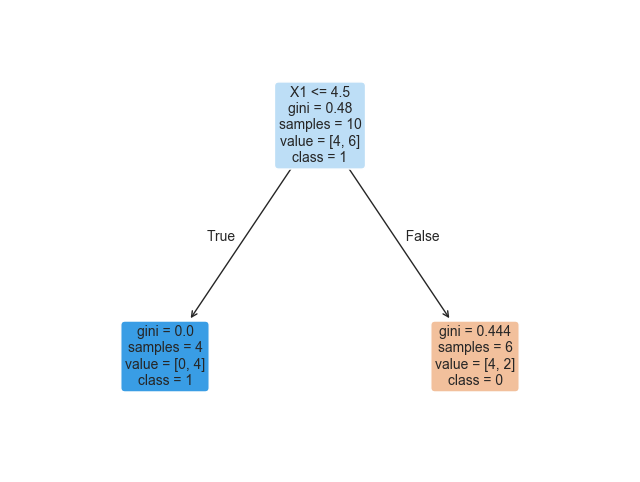

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


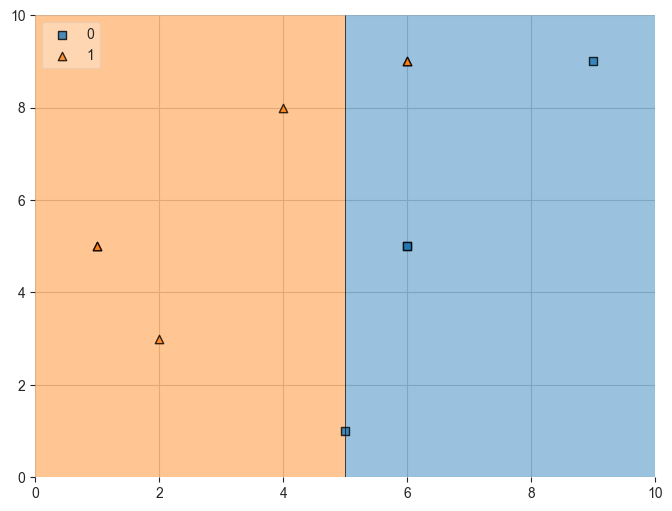

In [19]:
X = df2.iloc[:, :2]
y = df2.iloc[:, 2]
dt2 = plot_tree_and_decision_region(X, y)

In [20]:
### 3. Calculate y_pred
df2['y_pred'] = dt2.predict(X)

# 4. Alpha

error = calculate_error(df2)

alpha2 = calculate_alpha(error)

### 5. Update Weight
df2['updated_weight'] = df2.apply(lambda row: update_weight(row=row, alpha=alpha2), axis=1)

### 6. Normalized Weight
df2['normalized_weight'] = df2['updated_weight'] / df2['updated_weight'].sum()

### 7. Range
temp = np.cumsum(df2['normalized_weight'])

df2['cumsum_lower'] = temp - df2['normalized_weight']
df2['cumsum_upper'] = temp
df2

,X1,X2,label,weight,y_pred,updated_weight,normalized_weight,cumsum_lower,cumsum_upper
3,4,8,1,0.1,1,0.05,0.0625,0.0000,0.0625
1,2,3,1,0.1,1,0.05,0.0625,0.0625,0.1250
5,6,9,1,0.1,0,0.20,0.2500,0.1250,0.3750
8,9,9,0,0.1,0,0.05,0.0625,0.3750,0.4375
0,1,5,1,0.1,1,0.05,0.0625,0.4375,0.5000
6,6,5,0,0.1,0,0.05,0.0625,0.5000,0.5625
0,1,5,1,0.1,1,0.05,0.0625,0.5625,0.6250
5,6,9,1,0.1,0,0.20,0.2500,0.6250,0.8750
4,5,1,0,0.1,0,0.05,0.0625,0.8750,0.9375
6,6,5,0,0.1,0,0.05,0.0625,0.9375,1.0000


# Iter 3 

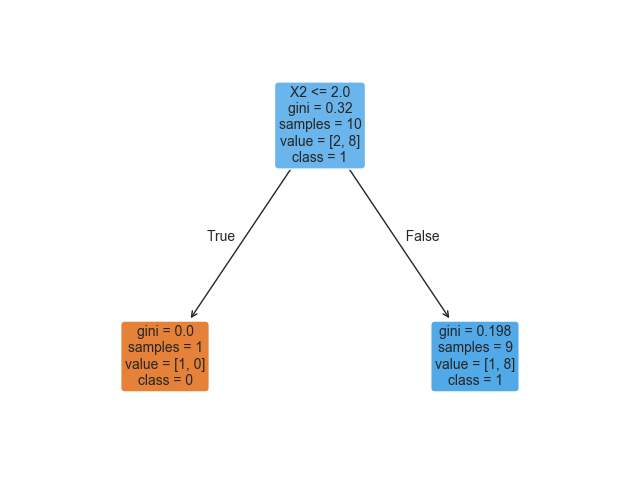

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


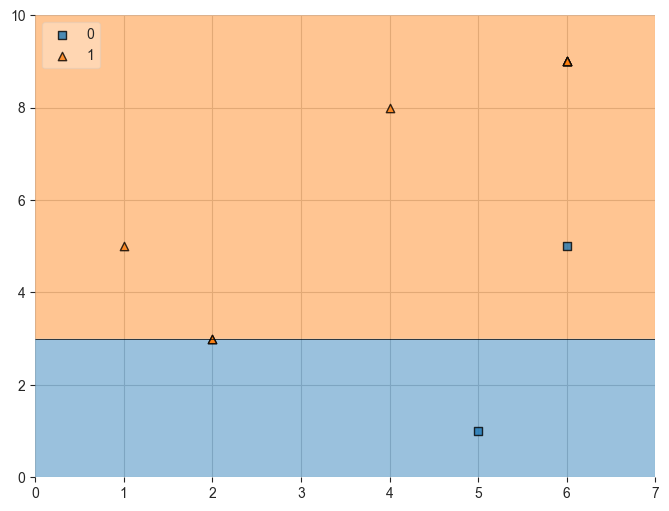

,X1,X2,label,weight,y_pred,updated_weight,normalized_weight,cumsum_lower,cumsum_upper
4,5,1,0,0.1,0,0.033333,0.055556,0.000000,0.055556
6,6,5,0,0.1,1,0.300000,0.500000,0.055556,0.555555
0,1,5,1,0.1,1,0.033333,0.055556,0.555555,0.611111
5,6,9,1,0.1,1,0.033333,0.055556,0.611111,0.666667
1,2,3,1,0.1,1,0.033333,0.055556,0.666667,0.722222
3,4,8,1,0.1,1,0.033333,0.055556,0.722222,0.777778
5,6,9,1,0.1,1,0.033333,0.055556,0.777778,0.833333
5,6,9,1,0.1,1,0.033333,0.055556,0.833333,0.888889
5,6,9,1,0.1,1,0.033333,0.055556,0.888889,0.944444
1,2,3,1,0.1,1,0.033333,0.055556,0.944444,1.000000


In [21]:
index_values = create_new_sample(df2)

df3 = df.iloc[index_values, :4]

X = df3.iloc[:, :2]
y = df3.iloc[:, 2]
dt3 = plot_tree_and_decision_region(X, y)
### 3. Calculate y_pred
df3['y_pred'] = dt3.predict(X)

# 4. Alpha

error = calculate_error(df3)

alpha3 = calculate_alpha(error)

### 5. Update Weight
df3['updated_weight'] = df3.apply(lambda row: update_weight(row=row, alpha=alpha3), axis=1)

### 6. Normalized Weight
df3['normalized_weight'] = df3['updated_weight'] / df3['updated_weight'].sum()

### 7. Range
temp = np.cumsum(df3['normalized_weight'])

df3['cumsum_lower'] = temp - df3['normalized_weight']
df3['cumsum_upper'] = temp
df3